In [1]:
!pip install -q causaldata pgmpy numpyro shap networkx

import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
import numpyro, numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
from sklearn.linear_model import LogisticRegression, LinearRegression
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator as MLE
from pgmpy.inference import VariableElimination
import shap

BG='#0a0e14'; FG='#c9d1d9'; CY='#22d3ee'; TE='#2dd4bf'; AM='#fbbf24'; GR='#1f2733'
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,
    'axes.edgecolor':GR,'axes.labelcolor':FG,'text.color':FG,'xtick.color':FG,'ytick.color':FG,
    'grid.color':GR,'font.family':'DejaVu Sans Mono','font.size':10,
    'axes.titlecolor':CY,'figure.dpi':120})
numpyro.set_host_device_count(1)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 42.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 12.5 MB/s eta 0:00:00


# VERİ

In [2]:
from causaldata import nhefs
raw = nhefs.load_pandas().data[['age','sex','qsmk','wt82_71','death']].dropna().copy()
raw.columns = ['U','C','T','M','O']
raw['C']=raw['C'].astype(int); raw['T']=raw['T'].astype(int); raw['O']=raw['O'].astype(int)

feat=['U','C','M']
X=raw[feat].values.astype('float32'); y=raw['O'].values.astype('float32')

rng=np.random.RandomState(42); perm=rng.permutation(len(X))
i1=int(.6*len(X)); i2=int(.8*len(X))
tr,va,te=perm[:i1],perm[i1:i2],perm[i2:]

mu,sd=X[tr].mean(0),X[tr].std(0)
Xtr=(X[tr]-mu)/sd; Xva=(X[va]-mu)/sd; Xte=(X[te]-mu)/sd
ytr,yva,yte=y[tr],y[va],y[te]

disc=pd.DataFrame({
    'U':pd.qcut(raw['U'],3,labels=False),'C':raw['C'],'T':raw['T'],
    'M':pd.qcut(raw['M'],3,labels=False),'O':raw['O']})
raw.describe().round(2)

,U,C,T,M,O
count,1566.00,1566.00,1566.00,1566.00,1566.00
mean,43.66,0.51,0.26,2.64,0.19
std,11.99,0.50,0.44,7.88,0.39
min,25.00,0.00,0.00,-41.28,0.00
25%,33.00,0.00,0.00,-1.48,0.00
50%,43.00,1.00,0.00,2.60,0.00
75%,53.00,1.00,1.00,6.69,0.00
max,74.00,1.00,1.00,48.54,1.00


# MODEL

## DAG

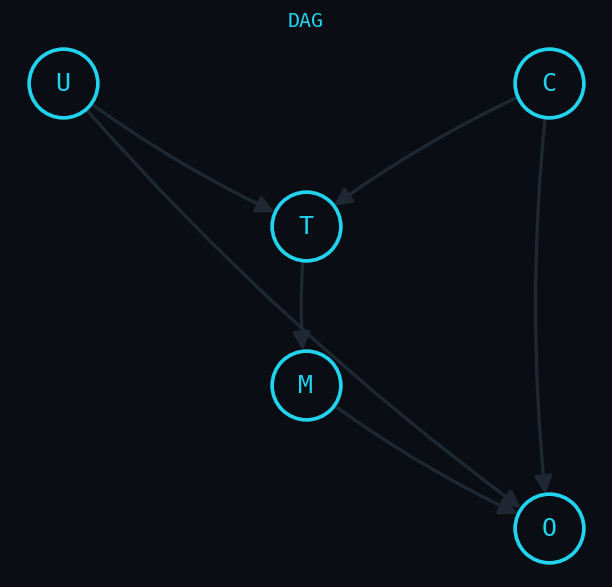

{'U': [], 'C': [], 'T': ['U', 'C'], 'M': ['T'], 'O': ['U', 'C', 'M']}

In [3]:
edges=[('U','T'),('C','T'),('T','M'),('U','O'),('C','O'),('M','O')]
nodes=['U','C','T','M','O']
Pa={n:[a for a,b in edges if b==n] for n in nodes}
G=nx.DiGraph(edges); G.add_nodes_from(nodes)

pos={'U':(-1.2,1.5),'C':(1.2,1.5),'T':(0,.5),'M':(0,-.6),'O':(1.2,-1.6)}
fig,ax=plt.subplots(figsize=(5.2,5))
nx.draw_networkx_edges(G,pos,ax=ax,edge_color=GR,width=2,arrowsize=22,
    connectionstyle='arc3,rad=.06',node_size=1700)
nx.draw_networkx_nodes(G,pos,ax=ax,node_size=1700,node_color=BG,edgecolors=CY,linewidths=2.2)
nx.draw_networkx_labels(G,pos,ax=ax,font_color=CY,font_size=15,font_family='monospace')
ax.set_title('DAG'); ax.axis('off'); plt.tight_layout(); plt.show()
Pa

## B-DAG

In [4]:
U=raw['U'].values.reshape(-1,1); C=raw['C'].values.reshape(-1,1)
T=raw['T'].values; M=raw['M'].values; O=raw['O'].values

fT=LogisticRegression(max_iter=1000).fit(np.hstack([U,C]),T)
fM=LinearRegression().fit(T.reshape(-1,1),M)
fO=LogisticRegression(max_iter=1000).fit(np.hstack([U,C,M.reshape(-1,1)]),O)

struct=pd.DataFrame({
    'X_i':['T','M','O'],
    'Pa(X_i)':[Pa['T'],Pa['M'],Pa['O']],
    'X_i = f(Pa(X_i))':['T = f(U,C)','M = f(T)','O = f(U,C,M)'],
    'skor':[round(fT.score(np.hstack([U,C]),T),3),
            round(fM.score(T.reshape(-1,1),M),3),
            round(fO.score(np.hstack([U,C,M.reshape(-1,1)]),O),3)]})
struct

,X_i,Pa(X_i),X_i = f(Pa(X_i)),skor
0,T,"[U, C]","T = f(U,C)",0.743
1,M,[T],M = f(T),0.020
2,O,"[U, C, M]","O = f(U,C,M)",0.849


## BN

In [5]:
bn=DiscreteBayesianNetwork(edges)
bn.add_cpds(*MLE(model=bn,data=disc).get_parameters())
assert bn.check_model()

joint='P(U,C,T,M,O) = P(U)·P(C)·P(T|U,C)·P(M|T)·P(O|U,C,M)'
ve=VariableElimination(bn)
P_TO=ve.query(['T','O'],show_progress=False)
P_O=ve.query(['O'],show_progress=False)
P_T_given_O=ve.query(['T'],evidence={'O':1},show_progress=False)

print(joint)
print('\nP(O):', np.round(P_O.values,4))
print('P(T|O=1) = P(T,O=1)/P(O=1):', np.round(P_T_given_O.values,4))
print(P_T_given_O)

P(U,C,T,M,O) = P(U)·P(C)·P(T|U,C)·P(M|T)·P(O|U,C,M)

P(O): [0.8207 0.1793]
P(T|O=1) = P(T,O=1)/P(O=1): [0.7017 0.2983]
+------+----------+
| T    |   phi(T) |
+======+==========+
| T(0) |   0.7017 |
+------+----------+
| T(1) |   0.2983 |
+------+----------+


## BNN

In [6]:
def bnn(X, y=None, H=16):
    D=X.shape[1]
    w1=numpyro.sample('w1', dist.Normal(0,1).expand([D,H]).to_event(2))
    b1=numpyro.sample('b1', dist.Normal(0,1).expand([H]).to_event(1))
    w2=numpyro.sample('w2', dist.Normal(0,1).expand([H,1]).to_event(2))
    b2=numpyro.sample('b2', dist.Normal(0,1).expand([1]).to_event(1))
    h=jnp.tanh(X@w1+b1)
    logits=(h@w2+b2).squeeze(-1)
    with numpyro.plate('data', X.shape[0]):
        numpyro.sample('obs', dist.Bernoulli(logits=logits), obs=y)

guide=AutoNormal(bnn)
svi=SVI(bnn, guide, numpyro.optim.Adam(1e-2), Trace_ELBO())
res=svi.run(jax.random.PRNGKey(0), 3000, jnp.array(Xtr), jnp.array(ytr))

post_pred=Predictive(bnn, guide=guide, params=res.params, num_samples=500)
def predict(Xin):
    s=post_pred(jax.random.PRNGKey(1), jnp.array(Xin))['obs']
    p=np.array(s.mean(0)); return p, (p>=0.5).astype(int)

proba_tr,yhat_tr=predict(Xtr)
proba_va,yhat_va=predict(Xva)
proba_te,yhat_te=predict(Xte)

proba=proba_te; yhat_reg=proba_te; yhat_cls=yhat_te

100%|██████████| 3000/3000 [00:13<00:00, 221.14it/s, init loss: 4083.5952, avg. loss [2851-3000]: 382.2824]


# DEĞERLENDİRME

## Regression Prediction

In [7]:
def reg_metrics(y_true, y_pred):
    e=y_true-y_pred
    AE=np.abs(e); MAE=AE.mean()
    SE=e**2; MSE=SE.mean(); SSE=SE.sum(); RMSE=np.sqrt(MSE)
    SST=((y_true-y_true.mean())**2).sum(); R2=1-SSE/SST
    return {'MAE':MAE,'MSE':MSE,'SSE':SSE,'RMSE':RMSE,'SST':SST,'R2':R2}

pd.DataFrame({'train':reg_metrics(ytr,proba_tr),
              'val':reg_metrics(yva,proba_va),
              'test':reg_metrics(yte,proba_te)}).round(4)

,train,val,test
MAE,0.215100,0.224300,0.234600
MSE,0.106900,0.120200,0.128600
SSE,100.375603,37.625401,40.385101
RMSE,0.326900,0.346700,0.358600
SST,140.494095,45.335499,50.955399
R2,0.285600,0.170100,0.207400


## Classification Prediction

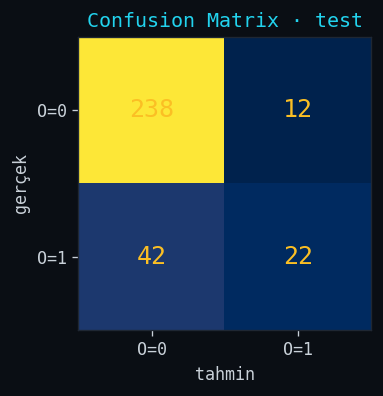

,train,val,test
Accuracy,0.8552,0.8403,0.8280
Precision,0.6579,0.5758,0.6471
Recall,0.4360,0.3455,0.3438
F1,0.5245,0.4318,0.4490


In [8]:
def cls_metrics(y_true, y_pred):
    TP=int(((y_pred==1)&(y_true==1)).sum()); TN=int(((y_pred==0)&(y_true==0)).sum())
    FP=int(((y_pred==1)&(y_true==0)).sum()); FN=int(((y_pred==0)&(y_true==1)).sum())
    acc=(TP+TN)/(TP+TN+FP+FN)
    prec=TP/(TP+FP) if TP+FP else 0.0
    rec=TP/(TP+FN) if TP+FN else 0.0
    f1=2*prec*rec/(prec+rec) if prec+rec else 0.0
    return TP,TN,FP,FN,{'Accuracy':acc,'Precision':prec,'Recall':rec,'F1':f1}

TP,TN,FP,FN,_=cls_metrics(yte,yhat_te)
cm=np.array([[TN,FP],[FN,TP]])
fig,ax=plt.subplots(figsize=(3.8,3.4))
ax.imshow(cm,cmap='cividis')
for (i,j),v in np.ndenumerate(cm): ax.text(j,i,v,ha='center',va='center',color=AM,fontsize=15)
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['O=0','O=1']); ax.set_yticklabels(['O=0','O=1'])
ax.set_xlabel('tahmin'); ax.set_ylabel('gerçek'); ax.set_title('Confusion Matrix · test')
plt.tight_layout(); plt.show()

pd.DataFrame({'train':cls_metrics(ytr,yhat_tr)[4],
              'val':cls_metrics(yva,yhat_va)[4],
              'test':cls_metrics(yte,yhat_te)[4]}).round(4)

# AÇIKLANABİLİRLİK

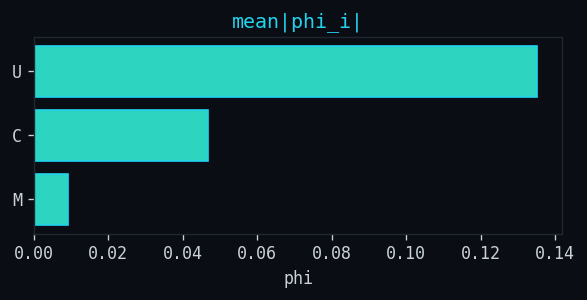

phi0 = 0.1711
f(x) = phi0 + sum(phi_i)   |   max|f - yhat_reg| = 0.042


,0
U,0.1352
C,0.0468
M,0.0091


In [9]:
def f_pred(Xin):
    s=Predictive(bnn, guide=guide, params=res.params, num_samples=200)(
        jax.random.PRNGKey(7), jnp.array(Xin.astype('float32')))['obs']
    return np.array(s.mean(0))

bg=shap.kmeans(Xtr,10)
expl=shap.KernelExplainer(f_pred, bg)
Xexp=Xte[:60]
phi=np.array(expl.shap_values(Xexp, nsamples=120, silent=True))
phi0=float(np.ravel(expl.expected_value)[0])

recon=phi0+phi.sum(1)
imp=np.abs(phi).mean(0)
order=np.argsort(imp)
fig,ax=plt.subplots(figsize=(5,2.6))
ax.barh([feat[i] for i in order], imp[order], color=TE, edgecolor=CY)
ax.set_title('mean|phi_i|'); ax.set_xlabel('phi'); plt.tight_layout(); plt.show()

print('phi0 =', round(phi0,4))
print('f(x) = phi0 + sum(phi_i)   |   max|f - yhat_reg| =', round(float(np.abs(recon-yhat_reg[:60]).max()),4))
pd.Series(dict(zip(feat, imp.round(4))))